In [206]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from datasets import load_dataset
from utils_exps import *
from scipy.stats import gamma 
from scipy.stats import beta 

In [207]:
folder = 'results/synthetic/final/'
alphas = pd.read_csv(folder+'alphas.csv')['alpha'].to_numpy()
table_diff_quant = pd.read_csv(folder+'table_diff_quant.csv')
#table_diff_quant = table_diff_quant.rename({'Unnamed: 0':'method'}, axis=1)

In [208]:
with open(folder+'qs.json', 'r', encoding='utf-8') as file:
    qs = json.load(file)

In [209]:
qs.keys()

dict_keys(['quant_tracking_multi_alpha', 'quant_tracking_simple_proj', 'quant_tracking_monotonic', 'quant_tracking_monotonic_fixed', 'quant_tracking_proj'])

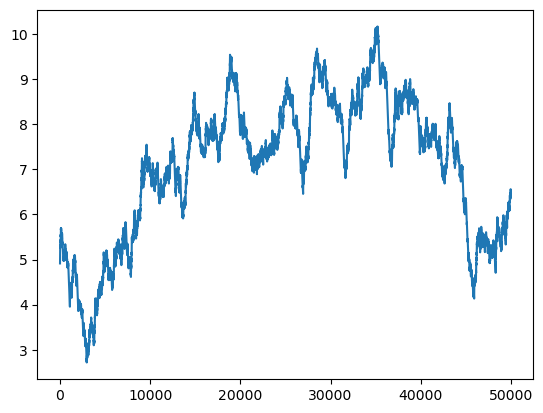

In [18]:
plt.plot(np.array(qs['quant_tracking_multi_alpha'][0])[:, 0])

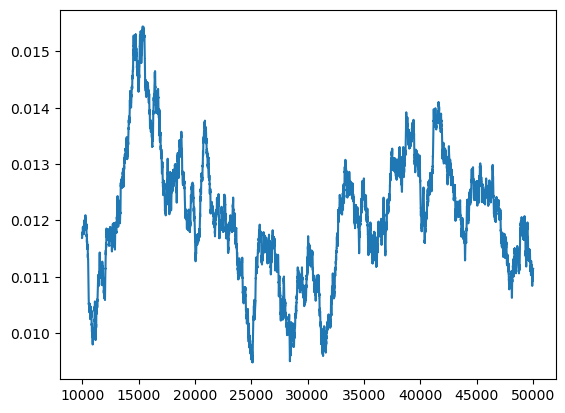

In [52]:
mean_ = np.mean(pd.concat([pd.DataFrame(np.sum(np.diff(np.array(qs['quant_tracking_multi_alpha'][i]), 1)>0, 1)).rolling(10000).mean() for i in range(10)], axis=1), 1)


In [75]:
np.mean(np.diff(np.array(qs[method][i]), 1)>0, 0)

array([0.01046, 0.01174, 0.01328, 0.016  , 0.01222, 0.01252, 0.0114 ,
       0.01024])

In [71]:
pd.DataFrame(np.sum(np.diff(np.array(qs[method][i]), 1)>0, 1)).rolling(10000).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
49995,0.0958
49996,0.0958
49997,0.0958
49998,0.0958


In [81]:
pd.DataFrame(np.mean(np.diff(np.array(qs[method][i]), 1)>0, 0))

,0
0,0.01046
1,0.01174
2,0.01328
3,0.01600
4,0.01222
5,0.01252
6,0.01140
7,0.01024


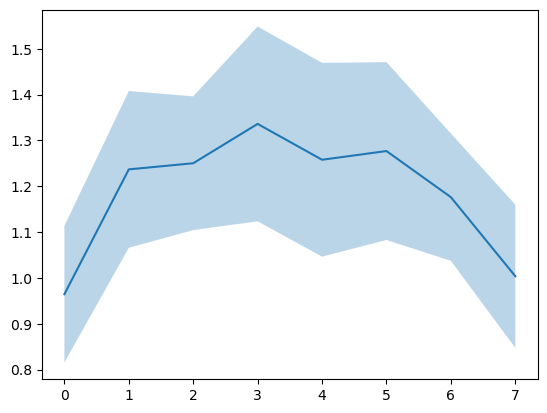

In [106]:
method = 'quant_tracking_multi_alpha'

mean_ = np.mean(pd.concat([pd.DataFrame(np.mean(np.diff(np.array(qs[method][i]), 1)>0, 0)) for i in range(10)], axis=1), 1)
std_ = np.std(pd.concat([pd.DataFrame(np.mean(np.diff(np.array(qs[method][i]), 1)>0, 0)) for i in range(10)], axis=1), 1)
plt.plot(100*mean_)

plt.fill_between(mean_.index, 
                 100*(mean_ - std_),
                100*(mean_ + std_), 
                 alpha=.3)

#plt.ylim(9*0.07, 9*0.13)

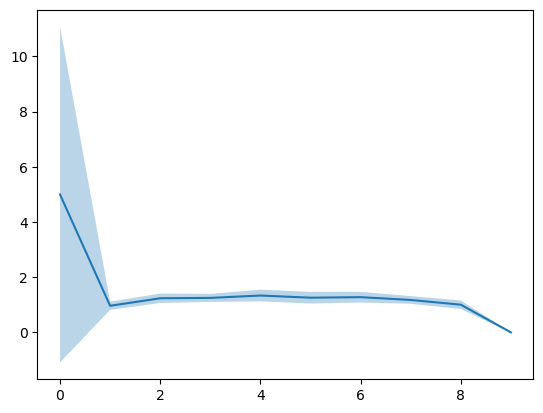

In [109]:
method = 'quant_tracking_multi_alpha'

mean_ = np.mean(pd.concat([pd.DataFrame(np.mean(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 0)) for i in range(10)], axis=1), 1)
std_ = np.std(pd.concat([pd.DataFrame(np.mean(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 0)) for i in range(10)], axis=1), 1)
plt.plot(100*mean_)

plt.fill_between(mean_.index, 
                 100*(mean_ - std_),
                100*(mean_ + std_), 
                 alpha=.3)


In [111]:
pd.concat([mean_, std_], axis=1)

,0,1
0,0.049964,0.060855
1,0.009646,0.001489
2,0.012368,0.001710
3,0.012502,0.001458
4,0.013360,0.002125
5,0.012578,0.002113
6,0.012768,0.001940
7,0.011762,0.001389
8,0.010038,0.001562
9,0.000000,0.000000


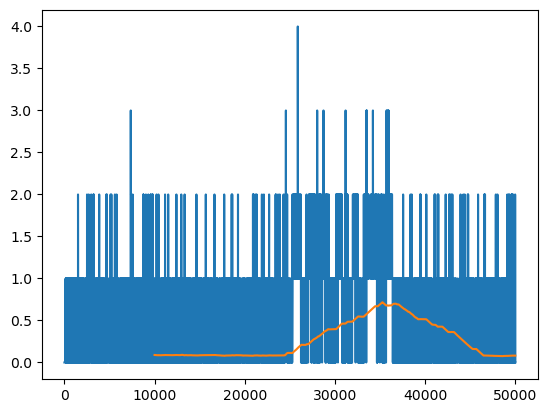

In [148]:
i = 6
plt.plot(np.sum(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1))
plt.plot(pd.DataFrame(np.sum(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(10000).mean())


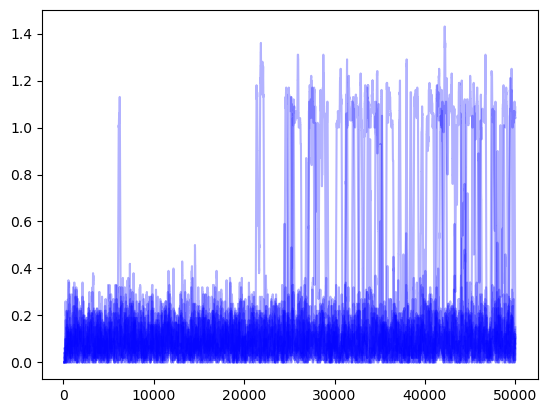

In [150]:
_ = plt.plot(pd.concat([pd.DataFrame(np.sum(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(100).mean() for i in range(10)], axis=1),
             color='b',
             alpha=.3)

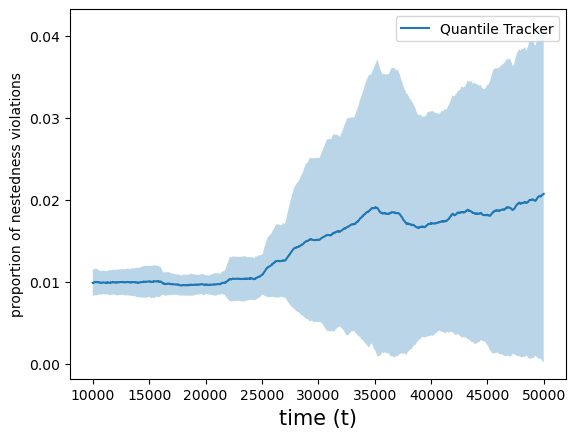

In [199]:
method = 'quant_tracking_multi_alpha'
#qs_arr = np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1)
#qs_arr = np.array(qs[method][i])

mean_ = np.mean(pd.concat([pd.DataFrame(np.sum(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(10000).mean() for i in range(10)], axis=1), 1)
std_ = np.std(pd.concat([pd.DataFrame(np.sum(np.diff(np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(10000).mean() for i in range(10)], axis=1), 1)
plt.plot(mean_/10, label='Quantile Tracker')

plt.fill_between(mean_.index, 
                 (mean_ - std_)/10,
                (mean_ + std_)/10, 
                 alpha=.3)

plt.ylabel('proportion of nestedness violations', fontsize=10)
plt.xlabel('time (t)', fontsize=15)
plt.legend()
#plt.ylim(9*0.07, 9*0.13)

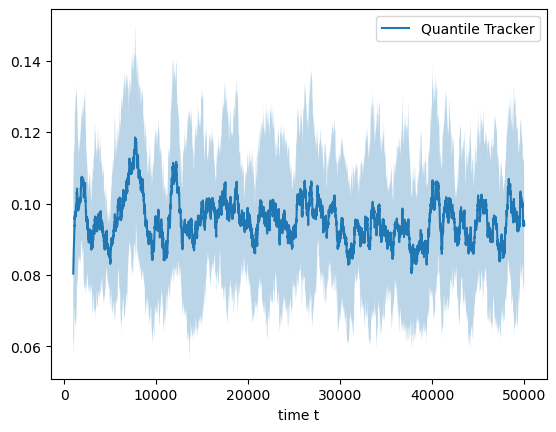

In [168]:
method = 'quant_tracking_multi_alpha'
#qs_arr = np.concatenate([10*np.ones((50000,1)), np.array(qs[method][i]), np.zeros((50000,1))], 1)
#qs_arr = np.array(qs[method][i])

mean_ = np.mean(pd.concat([pd.DataFrame(np.sum(np.diff(np.concatenate([np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(1000).mean() for i in range(10)], axis=1), 1)
std_ = np.std(pd.concat([pd.DataFrame(np.sum(np.diff(np.concatenate([np.array(qs[method][i]), np.zeros((50000,1))], 1), 1)>0, 1)).rolling(1000).mean() for i in range(10)], axis=1), 1)
plt.plot(mean_, label='Quantile Tracker')

plt.fill_between(mean_.index, 
                 (mean_ - std_),
                (mean_ + std_), 
                 alpha=.3)

plt.xlabel('time t')
plt.legend()
#plt.ylim(9*0.07, 9*0.13)

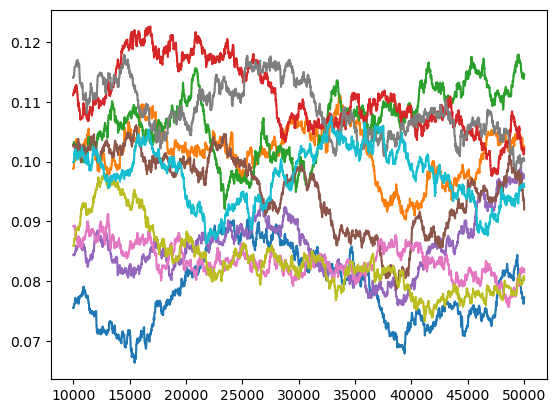

In [42]:
for i in range(10):
    plt.plot(pd.DataFrame(np.sum(np.diff(np.array(qs['quant_tracking_multi_alpha'][i]), 1)>0, 1)).rolling(10000).mean())
    

In [210]:
del table_diff_quant['Unnamed: 0']

In [211]:
table_mean = table_diff_quant.groupby('method').mean()
table_mean.columns = np.int64(table_mean.columns)
table_mean = table_mean.T

table_std = table_diff_quant.groupby('method').std()
table_std.columns = np.int64(table_std.columns)
table_std = table_std.T

In [212]:
table_mean.mean()

method
quant_tracking_monotonic          0.650921
quant_tracking_monotonic_fixed    0.785091
quant_tracking_multi_alpha        0.759106
quant_tracking_proj               0.757237
quant_tracking_simple_proj        0.758905
dtype: float64

In [213]:
method_list = [
    'quant_tracking_multi_alpha',
    'quant_tracking_simple_proj',
    'quant_tracking_monotonic',
    'quant_tracking_monotonic_fixed',
    'quant_tracking_proj'
] 

dict_methods = {
    'quant_tracking_multi_alpha': 'Quantile Tracker',
 'quant_tracking_simple_proj': 'Quantile Tracker Projected',
# 'quant_tracking_monotonic': 'Exponentiated Gradient',
 'quant_tracking_monotonic_fixed': 'Exponentiated Gradient',
 'quant_tracking_proj': 'Projected Gradient',
               }

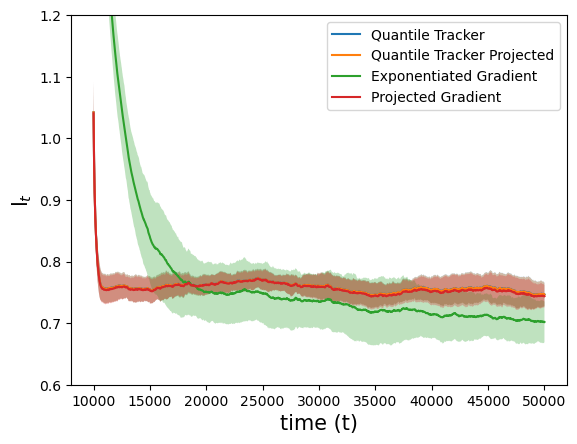

In [221]:


for m in dict_methods.keys():
    plt.plot(
        #np.log(table_mean[m]),
        table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.arange(table_mean.shape[0]),
        (table_mean[m] - table_std[m]),
        (table_mean[m] + table_std[m]),
        #np.log(table_mean[m] - table_std[m]),
        #np.log(table_mean[m] + table_std[m]),
        alpha=.3            
    )
    
plt.ylim(0.6, 1.2)
plt.ylabel(r'l$_t$', fontsize=15)
plt.xlabel('time (t)', fontsize=15)
plt.legend()

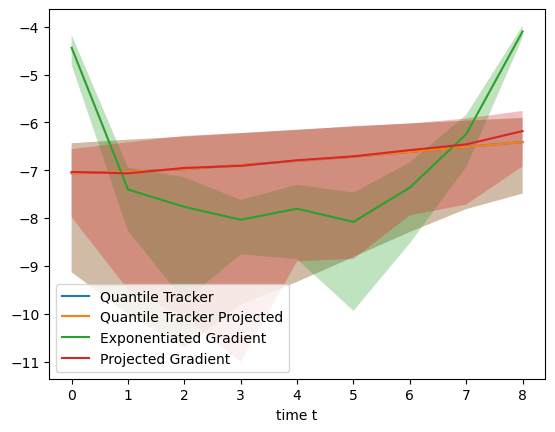

In [204]:


for m in dict_methods.keys():
    plt.plot(
        np.log(table_mean[m]),
        #table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.arange(table_mean.shape[0]),
        #(table_mean[m] - table_std[m]),
        #(table_mean[m] + table_std[m]),
        np.log(table_mean[m] - table_std[m]),
        np.log(table_mean[m] + table_std[m]),
        alpha=.3            
    )
    
#plt.ylim(5, 45)
plt.xlabel('time t')
plt.legend()

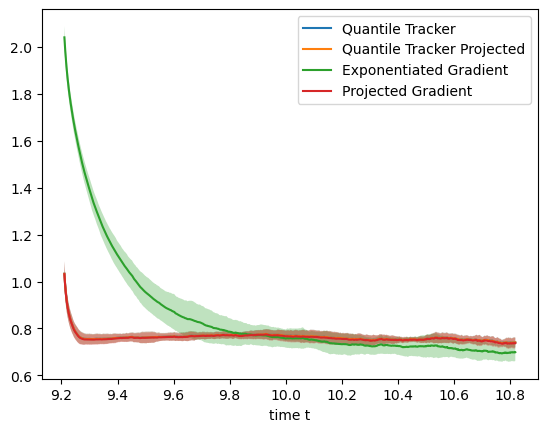

In [89]:


for m in dict_methods.keys():
    plt.plot(
        np.log(np.arange(1,1+table_mean.shape[0])),
        table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.log(np.arange(1,1+table_mean.shape[0])),
        table_mean[m] - table_std[m],
        table_mean[m] + table_std[m],
        alpha=.3            
    )
    
plt.xlabel('time t')
plt.legend()

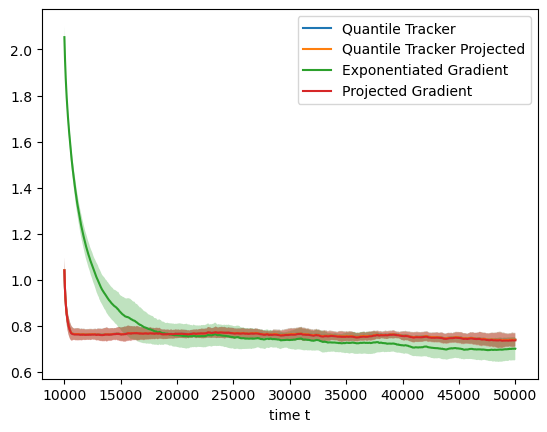

In [8]:
for m in dict_methods.keys():
    plt.plot(
        #np.log(table_mean[m]),
        table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.arange(table_mean.shape[0]),
        (table_mean[m] - table_std[m]),
        (table_mean[m] + table_std[m]),
        #np.log(table_mean[m] - table_std[m]),
        #np.log(table_mean[m] + table_std[m]),
        alpha=.3            
    )
    
plt.xlabel('time t')
plt.legend()

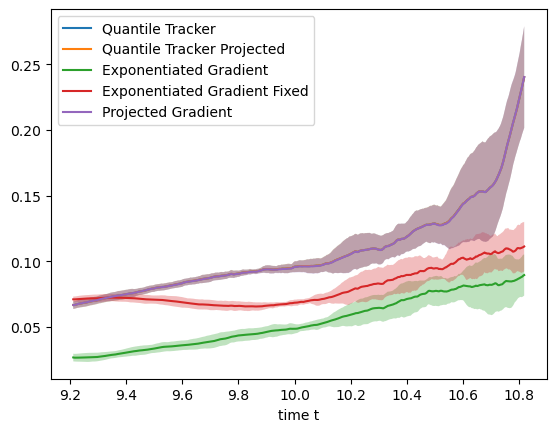

In [307]:
for m in dict_methods.keys():
    plt.plot(
        np.log(np.arange(1,1+table_mean.shape[0])),
        table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.log(np.arange(1,1+table_mean.shape[0])),
        table_mean[m] - table_std[m],
        table_mean[m] + table_std[m],
        alpha=.3            
    )
    
plt.xlabel('time t')
plt.legend()

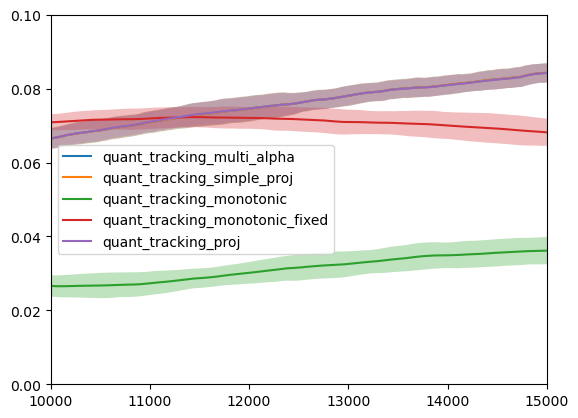

In [311]:


for m in method_list:
    plt.plot(
        table_mean[m],
        label=m
    )
    plt.fill_between(
        np.arange(table_mean.shape[0]),
        table_mean[m] - table_std[m],
        table_mean[m] + table_std[m],
        alpha=.3            
    )

plt.xlim(10000, 15000)
plt.ylim(0, .1)
plt.legend()

In [154]:
table_diff_cov = pd.read_csv(folder+'table_diff_cov.csv')
table_diff_cov = table_diff_cov.rename({'Unnamed: 0':'method'}, axis=1)

table_mean = table_diff_cov.groupby('method').mean()
table_mean.columns = np.int64(table_mean.columns)
table_mean = table_mean.T

table_std = table_diff_cov.groupby('method').std()
table_std.columns = np.int64(table_std.columns)
table_std = table_std.T

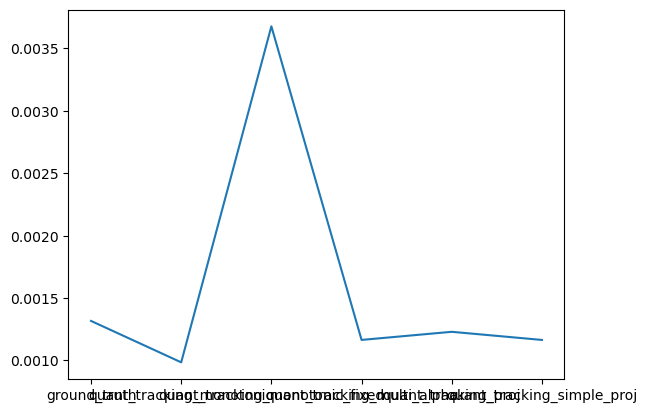

In [155]:
plt.plot(table_mean.mean())

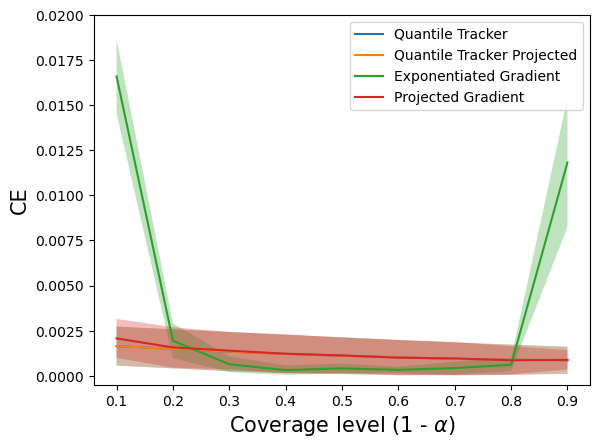

In [196]:

dict_methods = {
    'quant_tracking_multi_alpha': 'Quantile Tracker',
 'quant_tracking_simple_proj': 'Quantile Tracker Projected',
# 'quant_tracking_monotonic': 'Exponentiated Gradient',
    'quant_tracking_monotonic_fixed': 'Exponentiated Gradient',
 'quant_tracking_proj': 'Projected Gradient',
# 'empirical': 'Empirical',
# 'ground_truth': 'Ground Truth'
               }


for m in dict_methods.keys():
    plt.plot(
        1-alphas,
        table_mean[m],
        label=dict_methods[m]
            )
    plt.fill_between(
        1-alphas,
        table_mean[m] - table_std[m],
        table_mean[m] + table_std[m],
        alpha=.3
    )

plt.ylabel(r'CE', fontsize=15)
plt.xlabel(r'Coverage level (1 - $\alpha$)', fontsize=15)
#plt.xlabel('Coverage level')
plt.ylim(-0.0005,0.02)
plt.legend(loc='upper right')

In [53]:
table_set_size = pd.read_csv(folder+'table_set_size.csv')
table_set_size = table_set_size.rename({'Unnamed: 0':'method'}, axis=1)

In [54]:
table_set_size = pd.read_csv(folder+'table_set_size.csv')
table_set_size = table_set_size.rename({'Unnamed: 0':'method'}, axis=1)

table_mean = table_set_size.groupby('method').mean()
table_mean.columns = np.int64(table_mean.columns)
table_mean = table_mean.T

table_std = table_diff_cov.groupby('method').std()
table_std.columns = np.int64(table_std.columns)
table_std = table_std.T

In [55]:
dict_methods = {
     'quant_tracking_multi_alpha': 'Quantile Tracker',
     'quant_tracking_simple_proj': 'Quantile Tracker Projected',
     'quant_tracking_monotonic_fixed': 'Exponentiated Gradient Fixed', 
     'quant_tracking_monotonic': 'Exponentiated Gradient',
     'quant_tracking_proj': 'Projected Gradient',
               }

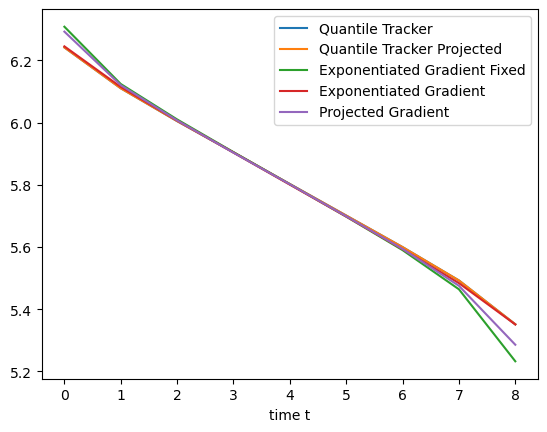

In [56]:


for m in dict_methods.keys():
    plt.plot(
        #np.log(table_mean[m]),
        table_mean[m],
        label=dict_methods[m]
    )
    plt.fill_between(
        np.arange(table_mean.shape[0]),
        (table_mean[m] - table_std[m]),
        (table_mean[m] + table_std[m]),
        #np.log(table_mean[m] - table_std[m]),
        #np.log(table_mean[m] + table_std[m]),
        alpha=.3            
    )
    
plt.xlabel('time t')
plt.legend()